# Sample complexity for the half-filled Hubbard ground state

How many bitstring samples $k$ (drawn from $|\psi_0|^2$) does an AR-RNN need before VMC reaches chemical accuracy ($|\Delta E|/|E_0|\le 0.01$) in a small number of steps?

This notebook walks through the pipeline at small $L$, then renders the headline plots from cached sweep data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from m9 import (
    Hubbard, ARRNN, run_cell,
    train_mle, vmc_step, model_energy_exact,
    plot_steps_vs_samples, plot_k_for_steps,
)

torch.set_num_threads(4)


## 1. The Hubbard ground state

`Hubbard(L, U, t)` builds the 1D half-filled Hubbard Hamiltonian with periodic boundary conditions in the $(N_\uparrow=N_\downarrow=L/2)$ sector, runs ED, and exposes `H, E_0, psi_0, signs, states`.


sector dim 36, E_0 = -2.1027


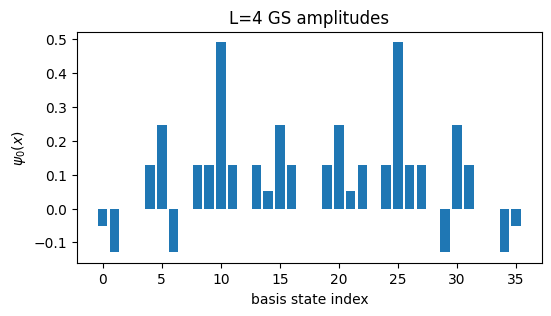

In [2]:
ctx = Hubbard(L=4, U=4.0)
print(f"sector dim {len(ctx.states)}, E_0 = {ctx.E_0:.4f}")
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(len(ctx.psi_0)), ctx.psi_0)
ax.set(xlabel="basis state index", ylabel=r"$\psi_0(x)$", title=f"L={ctx.L} GS amplitudes")
plt.show()


## 2. Sampling from $|\psi_0|^2$

`ctx.sample(k, rng)` draws $k$ bitstrings from the Born distribution via `numpy.random.choice` with weights $|\psi_0|^2$.


In [3]:
rng = np.random.default_rng(0)
bits = ctx.sample(1000, rng)
print("sample shape:", bits.shape)
print("first 5 samples:\n", bits[:5])


sample shape: (1000, 8)
first 5 samples:
 [[1 0 1 0 0 1 0 1]
 [0 1 0 1 1 0 1 0]
 [0 0 1 1 1 1 0 0]
 [1 0 1 0 1 1 0 0]
 [1 0 1 0 0 1 0 1]]


## 3. The AR-RNN

`ARRNN(L, n_up, n_dn, d_hidden)` is a single-layer GRU that models $\log|\psi(x)|^2$ over $\{0,1\}^{2L}$ with the $(N_\uparrow, N_\downarrow)$ sector mask enforced. Born rule: $q(x) = |\psi(x)|^2$.


In [4]:
torch.manual_seed(0)
model = ARRNN(L=ctx.L, n_up=2, n_dn=2, d_hidden=32)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params}")
print("untrained sample:", model.sample(3)[0].tolist())


parameters: 6498


untrained sample: [1, 0, 0, 1, 1, 0, 0, 1]


## 4. MLE pretrain

`train_mle(model, X, epochs, lr)` maximizes $\sum_i \log q(x_i)$.


In [5]:
E_pre = model_energy_exact(model, ctx)
print(f"untrained <H> = {E_pre:.4f}  rel = {(E_pre - ctx.E_0)/abs(ctx.E_0):+.3f}")
train_mle(model, bits, epochs=100, lr=2e-3, batch=32)
E_post = model_energy_exact(model, ctx)
print(f"post-MLE   <H> = {E_post:.4f}  rel = {(E_post - ctx.E_0)/abs(ctx.E_0):+.3f}")


untrained <H> = 1.6577  rel = +1.788


post-MLE   <H> = -2.0362  rel = +0.032


## 5. VMC training

Each `vmc_step` draws a batch, computes $E_{\rm loc}$ with off-diagonal hopping enumerated analytically (with JW signs from `ctx.signs`), and does one Adam step on the surrogate loss
$$ \mathcal{L}(\theta) = \langle \log|\psi_\theta(x)|\cdot (E_{\rm loc}(x) - \overline E)_{\rm detached}\rangle. $$


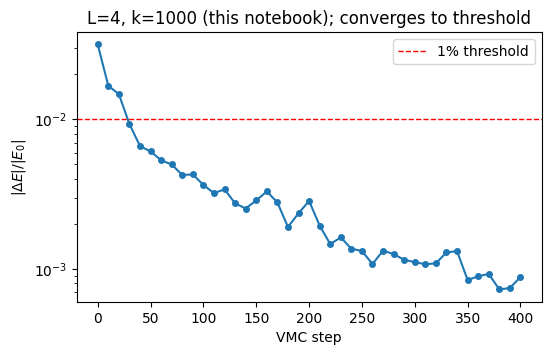

In [6]:
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
trace = [(0, E_post)]
for step in range(1, 401):
    vmc_step(model, ctx, opt, batch=256)
    if step % 10 == 0:
        trace.append((step, model_energy_exact(model, ctx)))
steps, energies = zip(*trace)
fig, ax = plt.subplots(figsize=(6, 3.5))
rel = [abs((e - ctx.E_0) / ctx.E_0) for e in energies]
ax.plot(steps, rel, "o-", ms=4)
ax.axhline(0.01, color="r", ls="--", lw=1, label="1% threshold")
ax.set(xlabel="VMC step", ylabel=r"$|\Delta E|/|E_0|$", yscale="log",
       title=f"L=4, k=1000 (this notebook); converges to threshold")
ax.legend(); plt.show()


## 6. A single cell end-to-end

`run_cell(L, k, seed)` packages all of the above (build ctx, init model, MLE pretrain on $k$ samples, VMC until 1% threshold or 5000 steps). Returns the steps-to-threshold record.


In [7]:
rec = run_cell(L=4, k=200, seed=0)
print(f"L={rec['L']} k={rec['k']}: steps_to_threshold = {rec['steps_to_threshold']}")


L=4 k=200: steps_to_threshold = 260


## 7. A small sequential sweep at L=4

Hubbard sample complexity should drop with $k$. Run a quick sweep and plot.


  k=0 s=0: steps=2790


  k=0 s=1: steps=640


  k=0 s=2: steps=None


  k=16 s=0: steps=None


  k=16 s=1: steps=1190


...

  k=128 s=1: steps=210


  k=128 s=2: steps=220


  k=200 s=0: steps=260


  k=200 s=1: steps=170


  k=200 s=2: steps=230


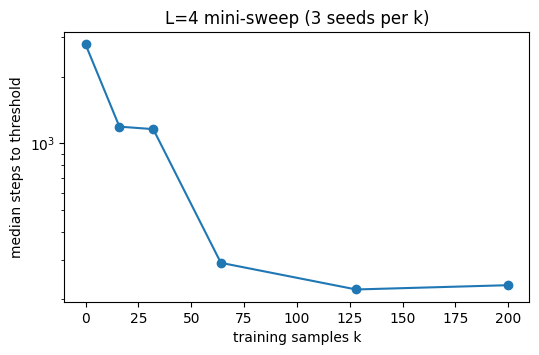

In [8]:
ks = [0, 16, 32, 64, 128, 200]
seeds = [0, 1, 2]
results = []
for k in ks:
    for s in seeds:
        r = run_cell(L=4, k=k, seed=s)
        results.append((k, s, r["steps_to_threshold"], r["max_steps"]))
        print(f"  k={k} s={s}: steps={r['steps_to_threshold']}")

import collections
by_k = collections.defaultdict(list)
for k, s, st, mx in results:
    by_k[k].append(st if st is not None else mx)
ks_sorted = sorted(by_k.keys())
medians = [np.median(by_k[k]) for k in ks_sorted]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ks_sorted, medians, "o-")
ax.set(xlabel="training samples k", ylabel="median steps to threshold",
       yscale="log", title="L=4 mini-sweep (3 seeds per k)")
plt.show()


## 8. Headline plots from the full sweep

The two M9 plots: median VMC steps vs $k$ (curves per $L$) and the inverse plot (samples needed to reach 30 VMC steps vs $L$). Generated from cached sweep data at `results/m9_cells/`.

To regenerate that data from scratch, run `python sweep.py --Ls 3,4,5,6,7 --seeds 8 --out cells/`.


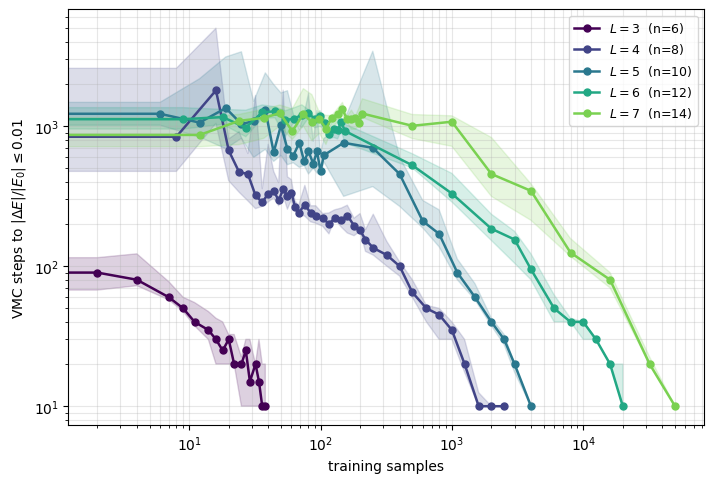

In [9]:
CELLS = "results/m9_cells"
PLOT_KMAX = {5: 4000, 6: 20000, 7: 50000}  # cap each curve at its first-reached floor

fig, ax = plt.subplots(figsize=(8.2, 5.4))
plot_steps_vs_samples(CELLS, plot_kmax=PLOT_KMAX, ax=ax)
plt.show()


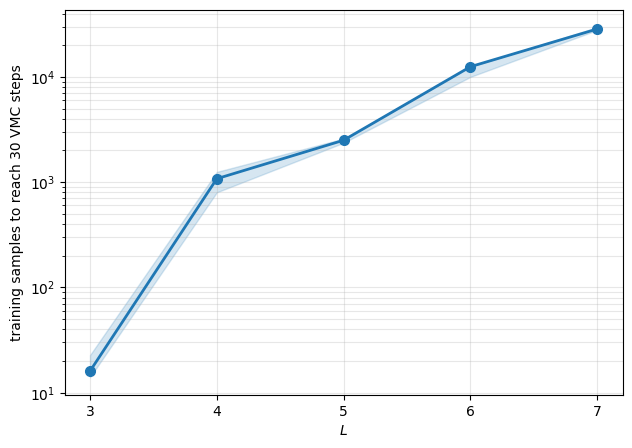

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
plot_k_for_steps(CELLS, target=30, ax=ax)
plt.show()
